In [1]:
# Cell 1: Import libraries and setup
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Cell 2: Define Cliff Walking Environment
class CliffWalkingEnvironment:
    """
    Cliff Walking Environment
    Grid: 4x12 where bottom row has a cliff from (3,1) to (3,10)
    Start: (3,0) - Bottom left
    Goal: (3,11) - Bottom right
    Cliff: (3,1) to (3,10) - Falling into cliff gives -100 reward and resets to start
    """
    
    def __init__(self, height=4, width=12):
        self.height = height
        self.width = width
        self.num_actions = 4
        self.actions = ['up', 'down', 'left', 'right']
        
        # Define special positions
        self.start_pos = (self.height - 1, 0)  # Bottom left
        self.goal_pos = (self.height - 1, self.width - 1)  # Bottom right
        
        # Define cliff positions (bottom row except start and goal)
        self.cliff_positions = set()
        for col in range(1, self.width - 1):
            self.cliff_positions.add((self.height - 1, col))
        
        self.current_pos = self.start_pos
        
    def reset(self):
        """Reset environment to start position"""
        self.current_pos = self.start_pos
        return self.current_pos
    
    def step(self, action):
        """Take action and return (next_state, reward, done)"""
        row, col = self.current_pos
        
        # Apply action
        if action == 0:  # up
            new_row = max(0, row - 1)
            new_col = col
        elif action == 1:  # down
            new_row = min(self.height - 1, row + 1)
            new_col = col
        elif action == 2:  # left
            new_row = row
            new_col = max(0, col - 1)
        elif action == 3:  # right
            new_row = row
            new_col = min(self.width - 1, col + 1)
        else:
            raise ValueError(f"Invalid action: {action}")
        
        next_pos = (new_row, new_col)
        
        # Determine reward and next state
        if next_pos in self.cliff_positions:
            # Fell into cliff
            reward = -100
            done = False
            next_pos = self.start_pos  # Reset to start
        elif next_pos == self.goal_pos:
            # Reached goal
            reward = -1  # Still -1 for the step, but episode ends
            done = True
        else:
            # Normal step
            reward = -1
            done = False
        
        self.current_pos = next_pos
        return next_pos, reward, done
    
    def get_state_id(self, pos):
        """Convert position to state ID"""
        row, col = pos
        return row * self.width + col
    
    def get_position(self, state_id):
        """Convert state ID to position"""
        row = state_id // self.width
        col = state_id % self.width
        return (row, col)
    
    def print_grid(self, policy=None, values=None):
        """Print the grid world"""
        print("\nCliff Walking Grid:")
        print("S = Start, G = Goal, C = Cliff, . = Safe")
        
        for row in range(self.height):
            row_str = ""
            for col in range(self.width):
                pos = (row, col)
                if pos == self.start_pos:
                    row_str += " S "
                elif pos == self.goal_pos:
                    row_str += " G "
                elif pos in self.cliff_positions:
                    row_str += " C "
                else:
                    row_str += " . "
            print(row_str)
        
        if policy is not None:
            print("\nPolicy (↑↓←→):")
            symbols = ['↑', '↓', '←', '→']
            for row in range(self.height):
                row_str = ""
                for col in range(self.width):
                    pos = (row, col)
                    if pos == self.goal_pos:
                        row_str += " G "
                    elif pos in self.cliff_positions:
                        row_str += " C "
                    else:
                        state_id = self.get_state_id(pos)
                        action = np.argmax(policy[state_id])
                        row_str += f" {symbols[action]} "
                print(row_str)
        
        if values is not None:
            print("\nState Values:")
            for row in range(self.height):
                row_str = ""
                for col in range(self.width):
                    pos = (row, col)
                    state_id = self.get_state_id(pos)
                    if pos in self.cliff_positions:
                        row_str += "   C  "
                    else:
                        row_str += f"{values[state_id]:5.1f} "
                print(row_str)

print("CliffWalkingEnvironment class defined!")

CliffWalkingEnvironment class defined!


In [4]:
# Cell 3: Test the environment and interaction
env = CliffWalkingEnvironment()
env.print_grid()

print(f"\nEnvironment details:")
print(f"Grid size: {env.height}x{env.width}")
print(f"Start position: {env.start_pos}")
print(f"Goal position: {env.goal_pos}")
print(f"Cliff positions: {len(env.cliff_positions)} cells")
print(f"Actions: {env.actions}")

print("\nTesting environment interaction:")
pos = env.reset()
print(f"Initial position: {pos}")

# Try different actions
test_actions = [3, 3, 1, 3]  # right, right, down, right
for i, action in enumerate(test_actions):
    next_pos, reward, done = env.step(action)
    print(f"Step {i+1}: Action '{env.actions[action]}' -> Position {next_pos}, Reward: {reward}, Done: {done}")
    if done:
        break


Cliff Walking Grid:
S = Start, G = Goal, C = Cliff, . = Safe
 .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  . 
 S  C  C  C  C  C  C  C  C  C  C  G 

Environment details:
Grid size: 4x12
Start position: (3, 0)
Goal position: (3, 11)
Cliff positions: 10 cells
Actions: ['up', 'down', 'left', 'right']

Testing environment interaction:
Initial position: (3, 0)
Step 1: Action 'right' -> Position (3, 0), Reward: -100, Done: False
Step 2: Action 'right' -> Position (3, 0), Reward: -100, Done: False
Step 3: Action 'down' -> Position (3, 0), Reward: -1, Done: False
Step 4: Action 'right' -> Position (3, 0), Reward: -100, Done: False


In [5]:
# Cell 4: Define Q-learning Agent
class QLearningAgent:
    """Q-learning Agent"""
    
    def __init__(self, num_states, num_actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.num_states = num_states
        self.num_actions = num_actions
        self.alpha = alpha      # Learning rate
        self.gamma = gamma      # Discount factor
        self.epsilon = epsilon  # Exploration rate
        
        # Initialize Q-table (state-action values)
        self.Q = np.zeros((num_states, num_actions))
        
        # Track learning statistics
        self.episode_count = 0
    
    def select_action(self, state):
        """Select action using epsilon-greedy policy"""
        if random.random() < self.epsilon:
            return random.randint(0, self.num_actions - 1)
        else:
            return np.argmax(self.Q[state])
    
    def q_learning_update(self, state, action, reward, next_state):
        """Perform Q-learning update: Q(s,a) ← Q(s,a) + α[r + γ max Q(s',a') - Q(s,a)]"""
        current_q = self.Q[state, action]
        max_next_q = np.max(self.Q[next_state])  # Key difference from SARSA
        
        td_target = reward + self.gamma * max_next_q
        td_error = td_target - current_q
        
        self.Q[state, action] += self.alpha * td_error
        
        return td_error
    
    def q_learning_update_terminal(self, state, action, reward):
        """Q-learning update for terminal states"""
        current_q = self.Q[state, action]
        td_target = reward  # No next state for terminal states
        td_error = td_target - current_q
        
        self.Q[state, action] += self.alpha * td_error
        
        return td_error
    
    def get_policy(self):
        """Extract greedy policy from Q-values"""
        return self.Q.copy()
    
    def get_value_function(self):
        """Extract value function (max Q-value for each state)"""
        return np.max(self.Q, axis=1)
    
    def decay_epsilon(self, decay_rate=0.995, min_epsilon=0.01):
        """Decay exploration rate"""
        self.epsilon = max(min_epsilon, self.epsilon * decay_rate)

print("QLearningAgent class defined!")

QLearningAgent class defined!


In [6]:
# Cell 5: Create and initialize Q-learning agent
num_states = env.height * env.width
agent = QLearningAgent(
    num_states=num_states,
    num_actions=env.num_actions,
    alpha=0.1,      # Learning rate
    gamma=0.9,      # Discount factor  
    epsilon=0.1     # Exploration rate
)

print("Q-learning Agent created with parameters:")
print(f"Number of states: {agent.num_states}")
print(f"Number of actions: {agent.num_actions}")
print(f"Learning rate (alpha): {agent.alpha}")
print(f"Discount factor (gamma): {agent.gamma}")
print(f"Exploration rate (epsilon): {agent.epsilon}")
print(f"Q-table shape: {agent.Q.shape}")

Q-learning Agent created with parameters:
Number of states: 48
Number of actions: 4
Learning rate (alpha): 0.1
Discount factor (gamma): 0.9
Exploration rate (epsilon): 0.1
Q-table shape: (48, 4)


In [7]:
# Cell 6: Train Q-learning agent with step-by-step demonstration and full training
print("Running a single Q-learning episode step-by-step:")

pos = env.reset()
state = env.get_state_id(pos)
action = agent.select_action(state)

print(f"Starting position: {pos}, state: {state}")
print(f"Initial action: {env.actions[action]}")

episode_reward = 0
step_count = 0
max_steps = 15  # Shortened for demo

while step_count < max_steps:
    print(f"\nStep {step_count + 1}:")
    print(f"Current state: {state} {env.get_position(state)}")
    print(f"Current action: {env.actions[action]}")
    print(f"Q-values for current state: {agent.Q[state]}")
    
    # Take action
    next_pos, reward, done = env.step(action)
    next_state = env.get_state_id(next_pos)
    
    print(f"Result: next_pos={next_pos}, reward={reward}, done={done}")
    
    if done:
        # Terminal state update
        td_error = agent.q_learning_update_terminal(state, action, reward)
        print(f"Q-learning update (terminal): Q({state},{action}) updated, TD error: {td_error:.3f}")
    else:
        # Q-learning update
        td_error = agent.q_learning_update(state, action, reward, next_state)
        print(f"Q-learning update: Q({state},{action}) updated, TD error: {td_error:.3f}")
        
        # Select next action
        action = agent.select_action(next_state)
        print(f"Next action: {env.actions[action]}")
    
    episode_reward += reward
    state = next_state
    step_count += 1
    
    if done:
        print(f"\nEpisode finished! Total reward: {episode_reward}, Steps: {step_count}")
        break

print("\n" + "="*60)
print("STARTING FULL TRAINING")
print("="*60)

def train_q_learning(env, agent, episodes=1000, verbose=True):
    """Train Q-learning agent"""
    
    episode_rewards = []
    episode_lengths = []
    td_errors_history = []
    
    if verbose:
        print(f"Starting Q-learning training for {episodes} episodes...")
    
    for episode in range(episodes):
        # Reset environment
        pos = env.reset()
        state = env.get_state_id(pos)
        
        episode_reward = 0
        episode_length = 0
        episode_td_errors = []
        max_steps = 200
        
        while episode_length < max_steps:
            # Select action
            action = agent.select_action(state)
            
            # Take action
            next_pos, reward, done = env.step(action)
            next_state = env.get_state_id(next_pos)
            
            if done:
                # Terminal state update
                td_error = agent.q_learning_update_terminal(state, action, reward)
            else:
                # Q-learning update
                td_error = agent.q_learning_update(state, action, reward, next_state)
            
            episode_td_errors.append(abs(td_error))
            episode_reward += reward
            state = next_state
            episode_length += 1
            
            if done:
                break
        
        episode_rewards.append(episode_reward)
        episode_lengths.append(episode_length)
        td_errors_history.append(np.mean(episode_td_errors))
        
        # Decay epsilon
        if episode % 100 == 0:
            agent.decay_epsilon()
        
        # Progress reporting
        if verbose and episode % 200 == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            avg_length = np.mean(episode_lengths[-100:])
            print(f"Episode {episode}: Avg Reward = {avg_reward:.1f}, "
                  f"Avg Length = {avg_length:.1f}, Epsilon = {agent.epsilon:.3f}")
    
    return episode_rewards, episode_lengths, td_errors_history

# Reset agent for fresh training
agent = QLearningAgent(
    num_states=num_states,
    num_actions=env.num_actions,
    alpha=0.1,      # Learning rate
    gamma=0.9,      # Discount factor  
    epsilon=0.1     # Exploration rate
)

print("Training Q-learning agent...")

episode_rewards, episode_lengths, td_errors = train_q_learning(
    env, agent, episodes=1000, verbose=True
)

print("Training completed!")
print(f"Final epsilon: {agent.epsilon:.3f}")
print(f"Final average reward (last 100 episodes): {np.mean(episode_rewards[-100:]):.1f}")
print(f"Final average episode length (last 100 episodes): {np.mean(episode_lengths[-100:]):.1f}")

Running a single Q-learning episode step-by-step:
Starting position: (3, 0), state: 36
Initial action: up

Step 1:
Current state: 36 (3, 0)
Current action: up
Q-values for current state: [0. 0. 0. 0.]
Result: next_pos=(2, 0), reward=-1, done=False
Q-learning update: Q(36,0) updated, TD error: -1.000
Next action: up

Step 2:
Current state: 24 (2, 0)
Current action: up
Q-values for current state: [0. 0. 0. 0.]
Result: next_pos=(1, 0), reward=-1, done=False
Q-learning update: Q(24,0) updated, TD error: -1.000
Next action: up

Step 3:
Current state: 12 (1, 0)
Current action: up
Q-values for current state: [0. 0. 0. 0.]
Result: next_pos=(0, 0), reward=-1, done=False
Q-learning update: Q(12,0) updated, TD error: -1.000
Next action: up

Step 4:
Current state: 0 (0, 0)
Current action: up
Q-values for current state: [0. 0. 0. 0.]
Result: next_pos=(0, 0), reward=-1, done=False
Q-learning update: Q(0,0) updated, TD error: -1.000
Next action: down

Step 5:
Current state: 0 (0, 0)
Current action: d


Cliff Walking Grid:
S = Start, G = Goal, C = Cliff, . = Safe
 .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  . 
 S  C  C  C  C  C  C  C  C  C  C  G 

Policy (↑↓←→):
 ←  ←  →  ←  →  →  →  →  →  ←  →  ↓ 
 →  →  →  ↓  →  ↓  →  →  ↓  →  →  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 ↑  C  C  C  C  C  C  C  C  C  C  G 

State Values:
 -7.0  -6.9  -6.7  -6.4  -6.1  -5.7  -5.3  -4.9  -4.4  -3.9  -3.3  -2.7 
 -7.2  -7.0  -6.7  -6.4  -6.1  -5.7  -5.2  -4.7  -4.1  -3.4  -2.7  -1.9 
 -7.2  -6.9  -6.5  -6.1  -5.7  -5.2  -4.7  -4.1  -3.4  -2.7  -1.9  -1.0 
 -7.5    C     C     C     C     C     C     C     C     C     C    0.0 


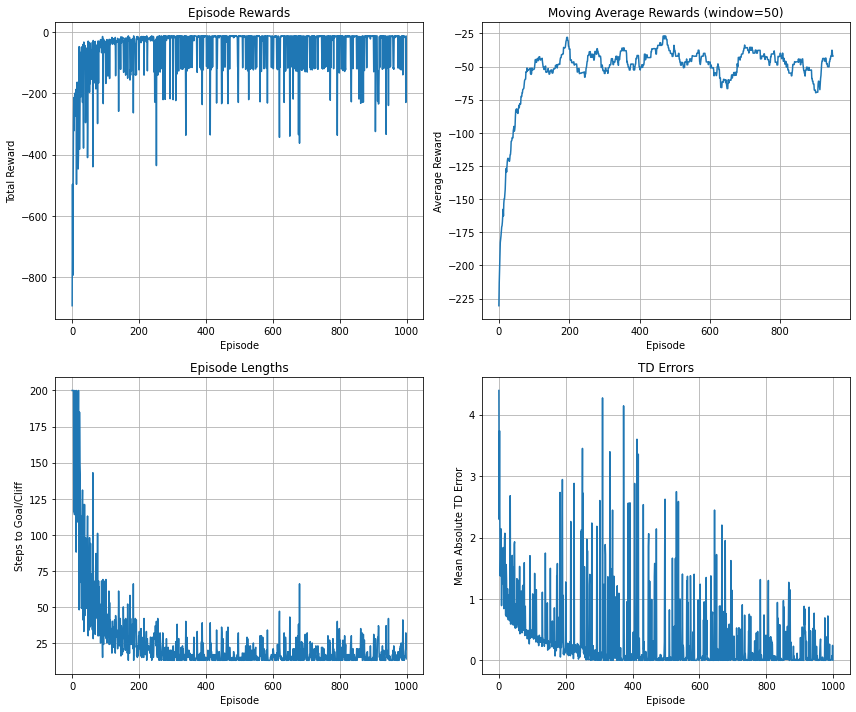

In [8]:
# Cell 7: Display results and learning curves
# Show learned policy and values
policy = agent.get_policy()
values = agent.get_value_function()

env.print_grid(policy=policy, values=values)

# Plot learning curves
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Episode rewards
ax1.plot(episode_rewards)
ax1.set_title('Episode Rewards')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.grid(True)

# Moving average of rewards
window = 50
if len(episode_rewards) >= window:
    moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    ax2.plot(moving_avg)
    ax2.set_title(f'Moving Average Rewards (window={window})')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Average Reward')
    ax2.grid(True)

# Episode lengths
ax3.plot(episode_lengths)
ax3.set_title('Episode Lengths')
ax3.set_xlabel('Episode')
ax3.set_ylabel('Steps to Goal/Cliff')
ax3.grid(True)

# TD errors
ax4.plot(td_errors)
ax4.set_title('TD Errors')
ax4.set_xlabel('Episode')
ax4.set_ylabel('Mean Absolute TD Error')
ax4.grid(True)

plt.tight_layout()
plt.show()

In [9]:
# Cell 8: Test learned policy
print("Testing learned policy...")

# Set epsilon to 0 for pure exploitation
test_agent = QLearningAgent(num_states, env.num_actions, epsilon=0)
test_agent.Q = agent.Q.copy()

test_episodes = 5
for episode in range(test_episodes):
    pos = env.reset()
    state = env.get_state_id(pos)
    
    print(f"\nTest Episode {episode + 1}:")
    print(f"Start: {pos}")
    
    episode_reward = 0
    path = [pos]
    
    for step in range(30):
        action = test_agent.select_action(state)
        next_pos, reward, done = env.step(action)
        next_state = env.get_state_id(next_pos)
        
        path.append(next_pos)
        episode_reward += reward
        
        print(f"  Step {step + 1}: {env.actions[action]} -> {next_pos} (reward: {reward})")
        
        state = next_state
        if done:
            break
    
    print(f"  Total reward: {episode_reward}")
    print(f"  Path length: {len(path) - .1}")

Testing learned policy...

Test Episode 1:
Start: (3, 0)
  Step 1: up -> (2, 0) (reward: -1)
  Step 2: right -> (2, 1) (reward: -1)
  Step 3: right -> (2, 2) (reward: -1)
  Step 4: right -> (2, 3) (reward: -1)
  Step 5: right -> (2, 4) (reward: -1)
  Step 6: right -> (2, 5) (reward: -1)
  Step 7: right -> (2, 6) (reward: -1)
  Step 8: right -> (2, 7) (reward: -1)
  Step 9: right -> (2, 8) (reward: -1)
  Step 10: right -> (2, 9) (reward: -1)
  Step 11: right -> (2, 10) (reward: -1)
  Step 12: right -> (2, 11) (reward: -1)
  Step 13: down -> (3, 11) (reward: -1)
  Total reward: -13
  Path length: 13.9

Test Episode 2:
Start: (3, 0)
  Step 1: up -> (2, 0) (reward: -1)
  Step 2: right -> (2, 1) (reward: -1)
  Step 3: right -> (2, 2) (reward: -1)
  Step 4: right -> (2, 3) (reward: -1)
  Step 5: right -> (2, 4) (reward: -1)
  Step 6: right -> (2, 5) (reward: -1)
  Step 7: right -> (2, 6) (reward: -1)
  Step 8: right -> (2, 7) (reward: -1)
  Step 9: right -> (2, 8) (reward: -1)
  Step 10: rig

Comparing different exploration strategies...
Training with epsilon = 0.01
  Final average reward: -16.3
Training with epsilon = 0.1
  Final average reward: -51.1
Training with epsilon = 0.3
  Final average reward: -159.9
Training with epsilon = 0.5
  Final average reward: -405.3


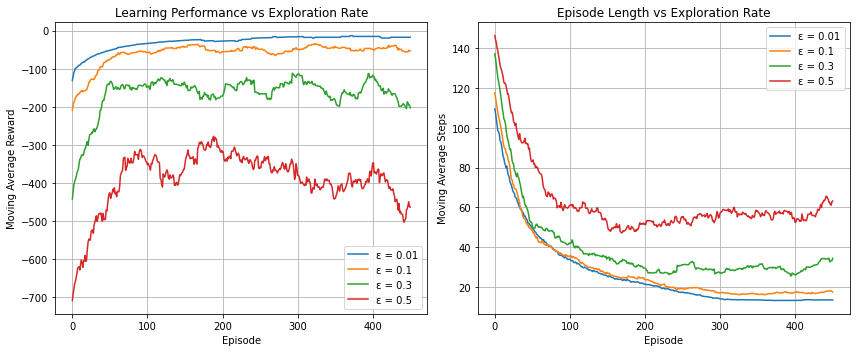


Q-learning Cliff Walking demonstration completed!
Key observations:
- Q-learning learns an optimal policy that avoids the cliff
- Higher exploration (epsilon) may explore more paths but takes longer to converge
- The agent learns to take the shortest path to the goal, balancing exploration and exploitation


In [10]:
# Cell 9: Compare with different epsilon values
print("Comparing different exploration strategies...")

epsilons = [0.01, 0.1, 0.3, 0.5]
comparison_results = {}

for eps in epsilons:
    print(f"Training with epsilon = {eps}")
    test_agent = QLearningAgent(num_states, env.num_actions, epsilon=eps, alpha=0.1, gamma=0.9)
    rewards, lengths, _ = train_q_learning(env, test_agent, episodes=500, verbose=False)
    comparison_results[eps] = {
        'rewards': rewards,
        'lengths': lengths,
        'final_avg_reward': np.mean(rewards[-100:])
    }
    print(f"  Final average reward: {comparison_results[eps]['final_avg_reward']:.1f}")

# Plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for eps, results in comparison_results.items():
    window = 50
    moving_avg = np.convolve(results['rewards'], np.ones(window)/window, mode='valid')
    plt.plot(moving_avg, label=f'ε = {eps}')
plt.title('Learning Performance vs Exploration Rate')
plt.xlabel('Episode')
plt.ylabel('Moving Average Reward')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for eps, results in comparison_results.items():
    window = 50
    moving_avg = np.convolve(results['lengths'], np.ones(window)/window, mode='valid')
    plt.plot(moving_avg, label=f'ε = {eps}')
plt.title('Episode Length vs Exploration Rate')
plt.xlabel('Episode')
plt.ylabel('Moving Average Steps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nQ-learning Cliff Walking demonstration completed!")
print("Key observations:")
print("- Q-learning learns an optimal policy that avoids the cliff")
print("- Higher exploration (epsilon) may explore more paths but takes longer to converge")
print("- The agent learns to take the shortest path to the goal, balancing exploration and exploitation")